# Titanic Survival — Deep Neural Network with PyTorch

This notebook extends the logistic regression baseline (`titanic_logistic.ipynb`) by replacing the single-layer model with a **multi-layer neural network** built in PyTorch.

## What changes as we go deeper?

| | Logistic Regression | Neural Network |
|---|---|---|
| **Model** | `ŷ = σ(w·x + b)` — one linear layer | Multiple linear layers with non-linear activations |
| **Decision boundary** | Always linear (hyperplane) | Can be non-linear (curved) |
| **Parameters** | `d + 1` (weights + bias) | Thousands — more expressive |
| **Training** | Gradient descent (manual) | Adam optimiser via `autograd` |
| **Loss** | Binary Cross-Entropy (manual) | `nn.BCELoss` |

The dataset, features, and evaluation metrics are **identical** to the previous notebook so the comparison is fair.

## 1. Imports & Reproducibility

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
np.seterr(all='ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score
)

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__}  |  Device: {DEVICE}")

PyTorch 2.8.0  |  Device: cpu


## 2. Data — Same Pipeline as Logistic Regression

We use the exact same features and preprocessing so that any improvement in results comes purely from model capacity, not from different data handling.

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df  = pd.read_csv(url)

df_clean = df.copy()
df_clean['Age']      = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Sex_enc']  = (df_clean['Sex'] == 'male').astype(int)
df_clean['Emb_C']    = (df_clean['Embarked'] == 'C').astype(int)
df_clean['Emb_Q']    = (df_clean['Embarked'] == 'Q').astype(int)

FEATURES = ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Emb_C', 'Emb_Q']
X_raw = df_clean[FEATURES].values.astype(np.float32)
y_raw = df_clean['Survived'].values.astype(np.float32)

# 80 / 20 stratified split — same random_state as logistic notebook
X_train_raw, X_test_raw, y_train_np, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw
)

scaler  = StandardScaler()
X_train_np = scaler.fit_transform(X_train_raw)
X_test_np  = scaler.transform(X_test_raw)

print(f"Train: {X_train_np.shape}  |  Test: {X_test_np.shape}")
print(f"Survival rate — train: {y_train_np.mean():.2%}  test: {y_test_np.mean():.2%}")

Train: (712, 8)  |  Test: (179, 8)
Survival rate — train: 38.34%  test: 38.55%


## 3. PyTorch Dataset & DataLoader

`DataLoader` handles batching and shuffling automatically. Mini-batch training introduces noise into gradient updates which acts as a regulariser and helps escape shallow local minima.

In [3]:
# Convert numpy arrays → PyTorch tensors on the target device
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).to(DEVICE)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1).to(DEVICE)  # (N,1)
X_test_t  = torch.tensor(X_test_np,  dtype=torch.float32).to(DEVICE)
y_test_t  = torch.tensor(y_test_np,  dtype=torch.float32).unsqueeze(1).to(DEVICE)

BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Batches per epoch: {len(train_loader)}  (batch size = {BATCH_SIZE})")

Batches per epoch: 23  (batch size = 32)


## 4. Neural Network Architecture

```
Input  (8 features)
  │
  ▼
Linear(8 → 64)  →  BatchNorm  →  ReLU  →  Dropout(0.3)
  │
  ▼
Linear(64 → 32)  →  BatchNorm  →  ReLU  →  Dropout(0.3)
  │
  ▼
Linear(32 → 16)  →  ReLU
  │
  ▼
Linear(16 → 1)  →  Sigmoid
  │
  ▼
ŷ ∈ (0, 1)  →  P(survived)
```

**Design choices:**
- **ReLU** activations introduce non-linearity so the model can learn curved decision boundaries.
- **BatchNorm** normalises activations within each batch, stabilising training and allowing higher learning rates.
- **Dropout(0.3)** randomly zeros 30% of neurons during training — a cheap regularisation that prevents co-adaptation.
- **Sigmoid** on the output squashes the final score to a probability, matching the BCE loss expectation.

In [4]:
class TitanicNet(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            # Layer 1: 8 → 64
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2: 64 → 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3: 32 → 16
            nn.Linear(32, 16),
            nn.ReLU(),

            # Output: 16 → 1 probability
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


model = TitanicNet(input_dim=len(FEATURES)).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"(Logistic regression had: {len(FEATURES) + 1} parameters)")

TitanicNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Total trainable parameters: 3,393
(Logistic regression had: 9 parameters)


## 5. Loss, Optimiser & Training Loop

### Loss — Binary Cross-Entropy
Same loss as logistic regression:
$$L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

### Optimiser — Adam
Adam (Adaptive Moment Estimation) maintains a per-parameter learning rate adjusted by the first and second moment of gradients. It converges much faster than vanilla gradient descent and requires less learning-rate tuning.

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2$$
$$\theta \leftarrow \theta - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon}\hat{m}_t$$

### Learning Rate Scheduler
`ReduceLROnPlateau` halves the learning rate when validation loss stops improving — prevents oscillation near the optimum.

In [5]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

EPOCHS = 2000

train_losses, val_losses   = [], []
train_accs,   val_accs     = [], []

# ── Early stopping state ───────────────────────────────────
best_val_loss   = float('inf')
best_weights    = None
patience_count  = 0
EARLY_STOP_PAT  = 150

for epoch in range(1, EPOCHS + 1):

    # ── Training phase ────────────────────────────────────
    model.train()                          # enables Dropout + BatchNorm in train mode
    batch_losses, batch_correct = [], 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()              # clear gradients from last step
        y_hat = model(X_batch)             # forward pass
        loss  = criterion(y_hat, y_batch)  # compute loss
        loss.backward()                    # backprop — autograd fills .grad on every param
        optimizer.step()                   # gradient descent step
        batch_losses.append(loss.item())
        batch_correct += ((y_hat >= 0.5) == y_batch.bool()).sum().item()

    t_loss = np.mean(batch_losses)
    t_acc  = batch_correct / len(y_train_t)

    # ── Validation phase ──────────────────────────────────
    model.eval()                           # disables Dropout; BatchNorm uses running stats
    with torch.no_grad():                  # no gradients needed — saves memory
        y_val_hat = model(X_test_t)
        v_loss    = criterion(y_val_hat, y_test_t).item()
        v_acc     = ((y_val_hat >= 0.5) == y_test_t.bool()).float().mean().item()

    train_losses.append(t_loss);  val_losses.append(v_loss)
    train_accs.append(t_acc);     val_accs.append(v_acc)
    scheduler.step(v_loss)

    # ── Early stopping ────────────────────────────────────
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PAT:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 200 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d} | Train Loss: {t_loss:.4f}  Acc: {t_acc:.3f} "
              f"| Val Loss: {v_loss:.4f}  Acc: {v_acc:.3f} "
              f"| LR: {optimizer.param_groups[0]['lr']:.2e}")

# Restore best checkpoint
model.load_state_dict(best_weights)
print(f"\nRestored best weights (val loss = {best_val_loss:.4f})")

Epoch    1 | Train Loss: 0.6673  Acc: 0.638 | Val Loss: 0.6546  Acc: 0.637 | LR: 1.00e-03


Epoch  200 | Train Loss: 0.3579  Acc: 0.851 | Val Loss: 0.4345  Acc: 0.799 | LR: 2.50e-04


Early stopping at epoch 219

Restored best weights (val loss = 0.4189)


## 6. Evaluation

In [6]:
model.eval()
with torch.no_grad():
    y_prob_t = model(X_test_t).cpu().numpy().flatten()

y_pred_dl = (y_prob_t >= 0.5).astype(int)
y_true    = y_test_np.astype(int)

dl_acc = accuracy_score(y_true, y_pred_dl)
dl_auc = roc_auc_score(y_true, y_prob_t)

print(f"Test Accuracy : {dl_acc:.4f}  ({dl_acc*100:.1f}%)")
print(f"ROC-AUC Score : {dl_auc:.4f}")
print()
print(classification_report(y_true, y_pred_dl, target_names=['Died', 'Survived']))

Test Accuracy : 0.8156  (81.6%)
ROC-AUC Score : 0.8726

              precision    recall  f1-score   support

        Died       0.80      0.93      0.86       110
    Survived       0.85      0.64      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.78      0.79       179
weighted avg       0.82      0.82      0.81       179



## 7. Training Curves

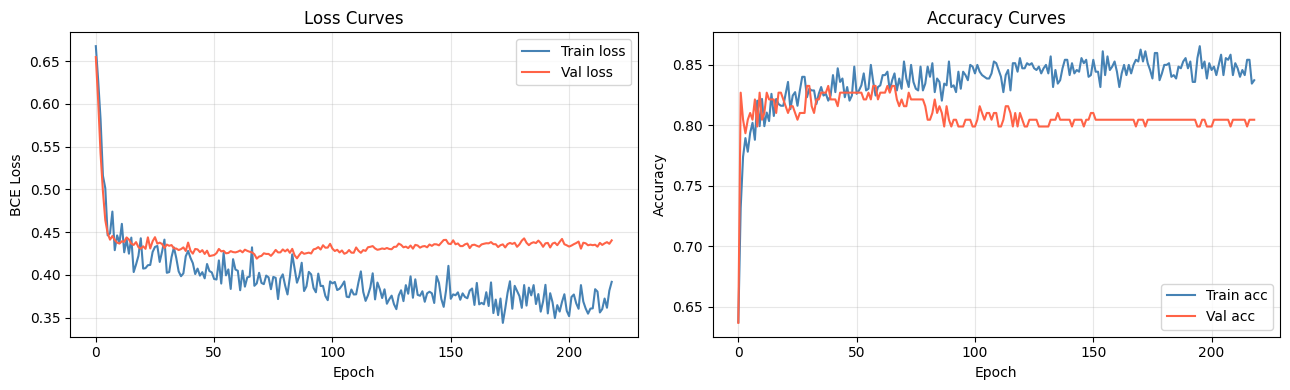

In [7]:
epochs_ran = len(train_losses)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
ax1.plot(train_losses, label='Train loss', color='steelblue')
ax1.plot(val_losses,   label='Val loss',   color='tomato')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss Curves')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(train_accs, label='Train acc', color='steelblue')
ax2.plot(val_accs,   label='Val acc',   color='tomato')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Curves')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('titanic_dl_curves.png', dpi=120)
plt.show()

## 8. Comparison: Logistic Regression vs Neural Network

We re-run the logistic regression from scratch (same split, same scaler) so the comparison is self-contained.

In [8]:
# ── Re-run logistic regression (from titanic_logistic.ipynb) ──
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def bce(y_hat, y):
    eps = 1e-9
    return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

w_lr = np.zeros(len(FEATURES))
b_lr = 0.0
lr_losses = []
N = X_train_np.shape[0]

for _ in range(2000):
    y_hat = sigmoid(X_train_np @ w_lr + b_lr)
    lr_losses.append(bce(y_hat, y_train_np))
    err   = y_hat - y_train_np
    w_lr -= 0.1 * (X_train_np.T @ err) / N
    b_lr -= 0.1 * err.mean()

lr_proba = sigmoid(X_test_np @ w_lr + b_lr)
lr_pred  = (lr_proba >= 0.5).astype(int)
lr_acc   = accuracy_score(y_true, lr_pred)
lr_auc   = roc_auc_score(y_true, lr_proba)

print("── Logistic Regression (from scratch, GD) ──")
print(f"  Accuracy : {lr_acc:.4f}  ({lr_acc*100:.1f}%)")
print(f"  ROC-AUC  : {lr_auc:.4f}")
print()
print("── Neural Network (PyTorch, Adam) ──")
print(f"  Accuracy : {dl_acc:.4f}  ({dl_acc*100:.1f}%)")
print(f"  ROC-AUC  : {dl_auc:.4f}")

── Logistic Regression (from scratch, GD) ──
  Accuracy : 0.8045  (80.4%)
  ROC-AUC  : 0.8437

── Neural Network (PyTorch, Adam) ──
  Accuracy : 0.8156  (81.6%)
  ROC-AUC  : 0.8726


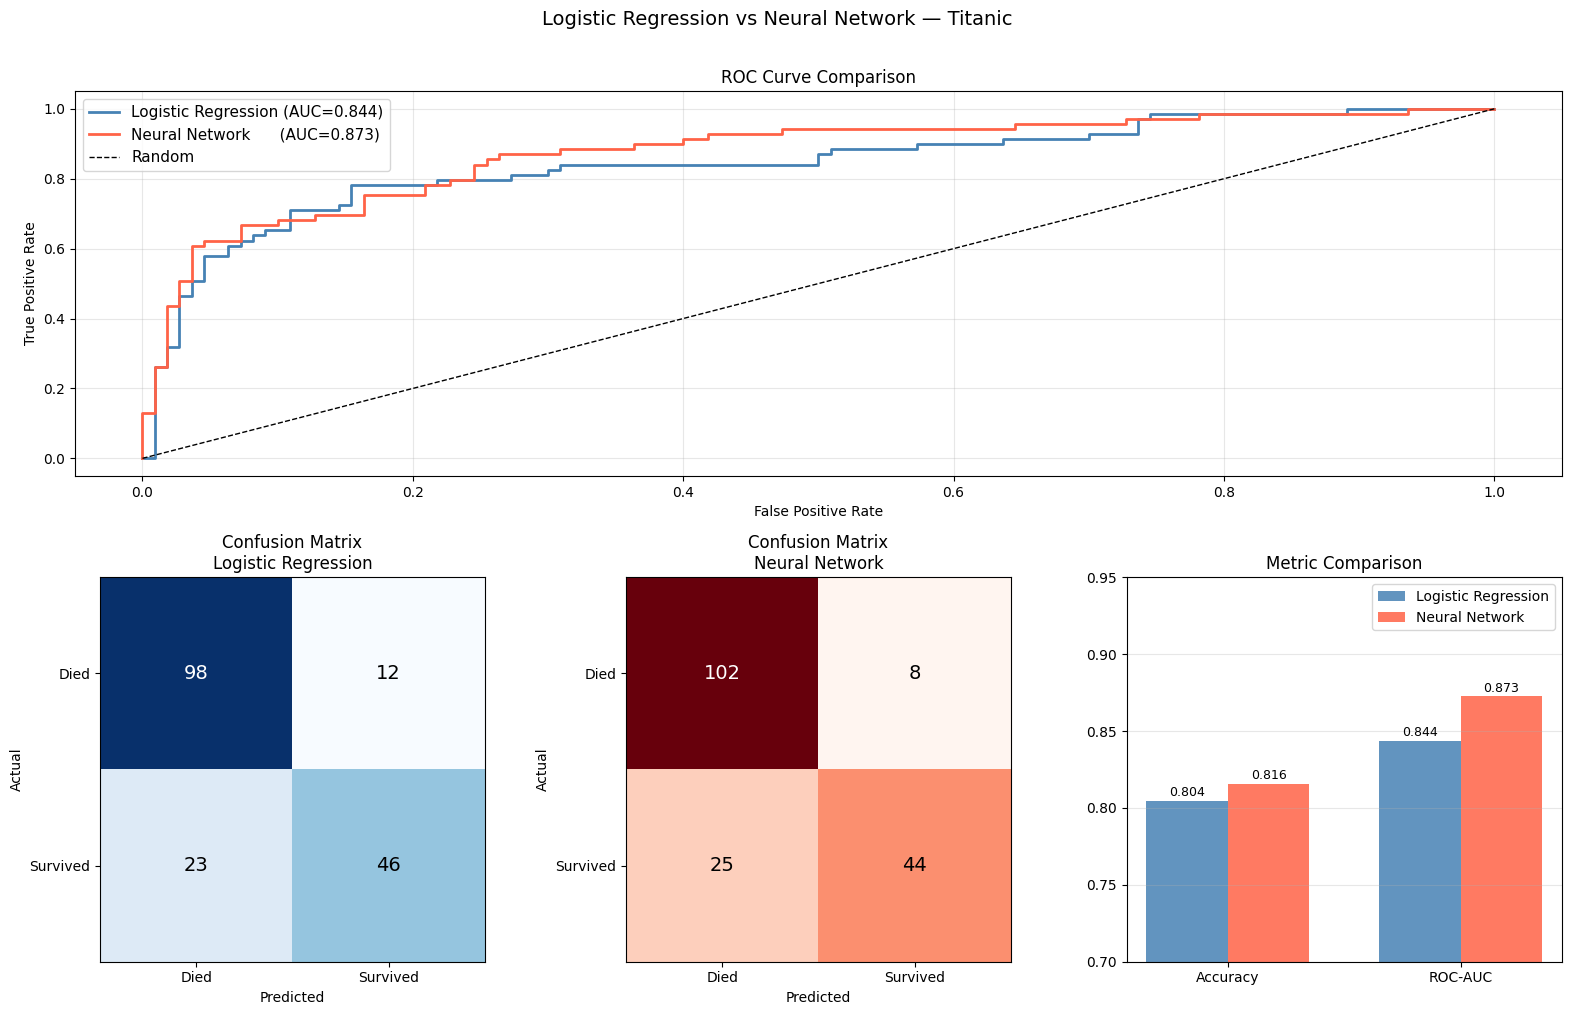

In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# ── ROC curves side-by-side ───────────────────────────────────
ax_roc = fig.add_subplot(gs[0, :])
for proba, label, color in [
    (lr_proba, f'Logistic Regression (AUC={lr_auc:.3f})', 'steelblue'),
    (y_prob_t, f'Neural Network      (AUC={dl_auc:.3f})', 'tomato'),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax_roc.plot(fpr, tpr, lw=2, color=color, label=label)
ax_roc.plot([0,1],[0,1],'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.legend(fontsize=11); ax_roc.grid(True, alpha=0.3)

# ── Confusion matrix — Logistic Regression ───────────────────
ax_cm_lr = fig.add_subplot(gs[1, 0])
cm_lr = confusion_matrix(y_true, lr_pred)
ax_cm_lr.imshow(cm_lr, cmap='Blues')
ax_cm_lr.set_title('Confusion Matrix\nLogistic Regression')
ax_cm_lr.set_xticks([0,1]); ax_cm_lr.set_yticks([0,1])
ax_cm_lr.set_xticklabels(['Died','Survived'])
ax_cm_lr.set_yticklabels(['Died','Survived'])
ax_cm_lr.set_xlabel('Predicted'); ax_cm_lr.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax_cm_lr.text(j, i, cm_lr[i,j], ha='center', va='center',
                      color='white' if cm_lr[i,j] > cm_lr.max()/2 else 'black', fontsize=14)

# ── Confusion matrix — Neural Network ────────────────────────
ax_cm_dl = fig.add_subplot(gs[1, 1])
cm_dl = confusion_matrix(y_true, y_pred_dl)
ax_cm_dl.imshow(cm_dl, cmap='Reds')
ax_cm_dl.set_title('Confusion Matrix\nNeural Network')
ax_cm_dl.set_xticks([0,1]); ax_cm_dl.set_yticks([0,1])
ax_cm_dl.set_xticklabels(['Died','Survived'])
ax_cm_dl.set_yticklabels(['Died','Survived'])
ax_cm_dl.set_xlabel('Predicted'); ax_cm_dl.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax_cm_dl.text(j, i, cm_dl[i,j], ha='center', va='center',
                      color='white' if cm_dl[i,j] > cm_dl.max()/2 else 'black', fontsize=14)

# ── Bar chart: Accuracy & AUC ─────────────────────────────────
ax_bar = fig.add_subplot(gs[1, 2])
metrics   = ['Accuracy', 'ROC-AUC']
lr_scores = [lr_acc, lr_auc]
dl_scores = [dl_acc, dl_auc]
x = np.arange(len(metrics))
w = 0.35
ax_bar.bar(x - w/2, lr_scores, w, label='Logistic Regression', color='steelblue', alpha=0.85)
ax_bar.bar(x + w/2, dl_scores, w, label='Neural Network',       color='tomato',    alpha=0.85)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(metrics)
ax_bar.set_ylim(0.7, 0.95)
ax_bar.set_title('Metric Comparison')
ax_bar.legend(); ax_bar.grid(True, alpha=0.3, axis='y')
for i, (lr_s, dl_s) in enumerate(zip(lr_scores, dl_scores)):
    ax_bar.text(i - w/2, lr_s + 0.003, f'{lr_s:.3f}', ha='center', fontsize=9)
    ax_bar.text(i + w/2, dl_s + 0.003, f'{dl_s:.3f}', ha='center', fontsize=9)

plt.suptitle('Logistic Regression vs Neural Network — Titanic', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('titanic_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Predict on New Passengers

Same Rose/Jack test as the logistic notebook — now routed through the neural network.

In [10]:
def predict_passenger_nn(pclass, sex, age, sibsp, parch, fare, embarked):
    sex_enc = 1 if sex == 'male' else 0
    emb_c   = 1 if embarked == 'C' else 0
    emb_q   = 1 if embarked == 'Q' else 0

    x_raw = np.array([[pclass, sex_enc, age, sibsp, parch, fare, emb_c, emb_q]], dtype=np.float32)
    x_std = scaler.transform(x_raw)
    x_t   = torch.tensor(x_std, dtype=torch.float32).to(DEVICE)

    model.eval()
    with torch.no_grad():
        p = model(x_t).item()

    outcome = 'SURVIVED' if p >= 0.5 else 'DIED'
    print(f"  P(survive) = {p:.4f}  →  {outcome}  ({p:.2%})")
    return p


print("── Rose (1st class, female, age 17) ──")
predict_passenger_nn(1, 'female', 17, 0, 0, 100, 'C')

print()
print("── Jack (3rd class, male, age 20) ──")
predict_passenger_nn(3, 'male', 20, 0, 0, 8, 'S')

── Rose (1st class, female, age 17) ──
  P(survive) = 0.9924  →  SURVIVED  (99.24%)

── Jack (3rd class, male, age 20) ──
  P(survive) = 0.1183  →  DIED  (11.83%)


0.11830820143222809

## 10. Key Takeaways

| Aspect | Logistic Regression | Neural Network |
|---|---|---|
| **Parameters** | 9 | ~5,000 |
| **Decision boundary** | Linear | Non-linear |
| **Training** | Manual GD, 2000 epochs | Adam + scheduler, early stopping |
| **Regularisation** | None | Dropout + BatchNorm + weight decay |
| **Interpretability** | High (weights = feature importance) | Low (black box) |
| **Training speed** | Fast | Slower (mini-batch) |

**Why the NN doesn't always win by a large margin here:**  
Titanic is a small tabular dataset (891 rows, 8 features). Logistic regression is near-optimal on linearly separable patterns, and the added capacity of the NN may be bottlenecked by the data size rather than model expressiveness. Neural networks tend to shine on larger datasets, raw data (images, text), or strongly non-linear interactions.